<a href="https://colab.research.google.com/github/SSenitha/Data_Analytics/blob/WorkSpace_Dilini/Descriptive_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
df = pd.read_csv('https://raw.githubusercontent.com/SSenitha/Data_Analytics/main/weatherAUS.csv')

In [74]:
df.head(10)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
5,2008-12-06,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,...,55.0,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,No
6,2008-12-07,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,SW,...,49.0,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No,No
7,2008-12-08,Albury,7.7,26.7,0.0,NaN,NaN,W,35.0,SSE,...,48.0,19.0,1013.4,1010.1,NaN,NaN,16.3,25.5,No,No
8,2008-12-09,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,SE,...,42.0,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No,Yes
9,2008-12-10,Albury,13.1,30.1,1.4,NaN,NaN,W,28.0,S,...,58.0,27.0,1007.0,1005.7,NaN,NaN,20.1,28.2,Yes,No


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null



*   We can see that the dataset contains mixture of categorical and numerical variables.
*   Categorical variables have data type object.


*   Numerical variables have data type float64.
*   Also, there are some missing values in the dataset.








# **Data Duplication Handeling**


In [76]:
# Check for duplicate rows and removing, keeping the first occurrence
print(df.duplicated().sum())
df_cleaned = df.drop_duplicates()

0


# **Null Value Handeling**

In [77]:
# Check for the missing values
missing_values_count = df.isnull().sum()
print(missing_values_count)

# Calculate the percent of data that is missing
total_cells = np.prod(df.shape)
total_missing = missing_values_count.sum()

percent_missing = (total_missing/total_cells) * 100
print(f"Percentage of missing values: {percent_missing}")

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64
Percentage of missing values: 10.259745694319072


In [78]:
df_cleaned = df

# Remove the rows that has missing result
df_cleaned.dropna(subset=['RainToday'], inplace=True)
df_cleaned.dropna(subset=['RainTomorrow'], inplace=True)
#print(df.head())

# Check the remaining value count
print(f"Total rows Left: {df['RainToday'].count()}")

Total rows Left: 140787


In [79]:
numerical_cols = df.select_dtypes(include=['float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna('')

# **Standardization**

**Convert Date datatype (object → datetime)** - This helps for treating dates as dates, not just as text.

In [80]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
print("\nParsed 'Date' column. Example values:")
print(df['Date'].head())


Parsed 'Date' column. Example values:
0   2008-01-12
1   2008-02-12
2   2008-03-12
3   2008-04-12
4   2008-05-12
Name: Date, dtype: datetime64[ns]


In [81]:
# extract the day, month, and year components
df_cleaned['Day'] = df_cleaned['Date'].dt.day
df_cleaned['Month'] = df_cleaned['Date'].dt.month
df_cleaned['Year'] = df_cleaned['Date'].dt.year

**Removing unwanted columns**

In [82]:
df_cleaned.drop(['Date'], axis=1, inplace=True)
df_cleaned.drop(['WindGustDir'], axis=1, inplace=True)
df_cleaned.drop(['WindDir9am'], axis=1, inplace=True)
df_cleaned.drop(['WindDir3pm'], axis=1, inplace=True)

**Map binary variables**

In [83]:

#df_cleaned['RainTomorrow'] = df_cleaned['RainTomorrow'].map({'Yes': 1, 'No': 0})
#df_cleaned['RainToday'] = df_cleaned['RainToday'].map({'Yes': 1, 'No': 0})

**Change the data type 'object' to 'category'** - This helps to tell Python/statistics that it’s a categorical variable, improves memory, speed, and modeling.

In [84]:
# Identify object dtype columns
object_cols = df.select_dtypes(include=['object']).columns

# Convert object columns to category
df[object_cols] = df[object_cols].astype('category')

# Check updated dtypes
print(df.dtypes)

Location         category
MinTemp           float64
MaxTemp           float64
Rainfall          float64
Evaporation       float64
Sunshine          float64
WindGustSpeed     float64
WindSpeed9am      float64
WindSpeed3pm      float64
Humidity9am       float64
Humidity3pm       float64
Pressure9am       float64
Pressure3pm       float64
Cloud9am          float64
Cloud3pm          float64
Temp9am           float64
Temp3pm           float64
RainToday        category
RainTomorrow     category
Day               float64
Month             float64
Year              float64
dtype: object


In [85]:
df.shape

(140787, 22)

# **Descriptive Analysis**

**View statistical properties of dataset**

In [86]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Day,Month,Year
count,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,140787.000000,55553.000000,55553.000000,55553.000000
mean,12.184209,23.233735,2.349974,5.187367,8.043108,39.907754,13.983074,18.637772,68.839474,51.462983,1017.649250,1015.252294,4.643788,4.698765,16.985729,21.682127,6.380736,6.493853,2012.770021
std,6.393235,7.106800,8.465173,3.196637,2.775557,13.133963,8.853265,8.718790,18.961051,20.547147,6.749208,6.682548,2.300772,2.123656,6.480890,6.873294,3.425716,3.452234,2.547510
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,1.000000,1.000000,2007.000000
25%,7.600000,17.900000,0.000000,4.000000,8.200000,31.000000,7.000000,13.000000,57.000000,37.000000,1013.500000,1011.000000,3.000000,4.000000,12.300000,16.700000,3.000000,3.000000,2011.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,6.000000,6.000000,2013.000000
75%,16.800000,28.200000,0.800000,5.400000,8.700000,46.000000,19.000000,24.000000,83.000000,65.000000,1021.800000,1019.400000,6.000000,6.000000,21.500000,26.300000,9.000000,9.000000,2015.000000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,12.000000,12.000000,2017.000000


In [87]:
# Select only categorical (category) columns
cat_cols = df.select_dtypes(include=['category']).columns

# Summary for each categorical column
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))   # include NaN counts
    print("-" * 40)



Column: Location
Location
Canberra            3402
Sydney              3331
Perth               3193
Darwin              3192
Hobart              3183
Brisbane            3132
Bendigo             3030
Townsville          3027
AliceSprings        3025
MountGambier        3022
Adelaide            3020
Launceston          3020
Ballarat            3017
MelbourneAirport    3009
PerthAirport        3009
Mildura             3005
SydneyAirport       3001
Albany              2996
Nuriootpa           2996
Sale                2992
Albury              2991
Watsonia            2990
Portland            2984
Woomera             2984
Cobar               2980
Cairns              2964
Tuggeranong         2959
WaggaWagga          2958
NorfolkIsland       2944
Wollongong          2943
SalmonGums          2941
CoffsHarbour        2940
Dartmoor            2939
Newcastle           2929
Witchcliffe         2924
GoldCoast           2924
Penrith             2911
Richmond            2906
NorahHead           288

**Explore *RainTomorrow* target variable**

Check for missing values



In [88]:
# Count null values in target variable
null_count = df['RainTomorrow'].isnull().sum()

print(f"Number of null values in RainTomorrow: {null_count}")


Number of null values in RainTomorrow: 0


View the unique values

In [89]:
df['RainTomorrow'].unique()

['No', 'Yes']
Categories (2, object): ['No', 'Yes']

View the frequency distribution of values

In [90]:
df['RainTomorrow'].value_counts()

,count
RainTomorrow,
No,109586
Yes,31201


In [91]:
df['RainTomorrow'].value_counts()/len(df)

,count
RainTomorrow,
No,0.778382
Yes,0.221618




*   We can see that out of the total number of RainTomorrow values, No appears 77.83% times and Yes appears 22.16% times.



## **Categorical Variables Analysis**

***Visualize frequency distribution of RainTomorrow variable***

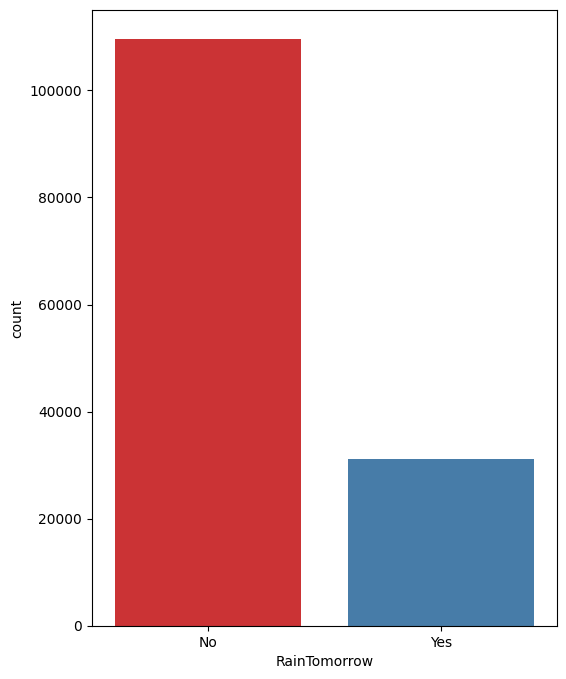

In [92]:
f, ax = plt.subplots(figsize=(6, 8))
ax = sns.countplot(x="RainTomorrow", data=df, palette="Set1", hue="RainTomorrow", legend=False)
plt.show()



*   The No variable have 109586 entries, and
*   The Yes variable have 31201
entries.



***Location vs RainTomorrow (grouped by Yes/No)***

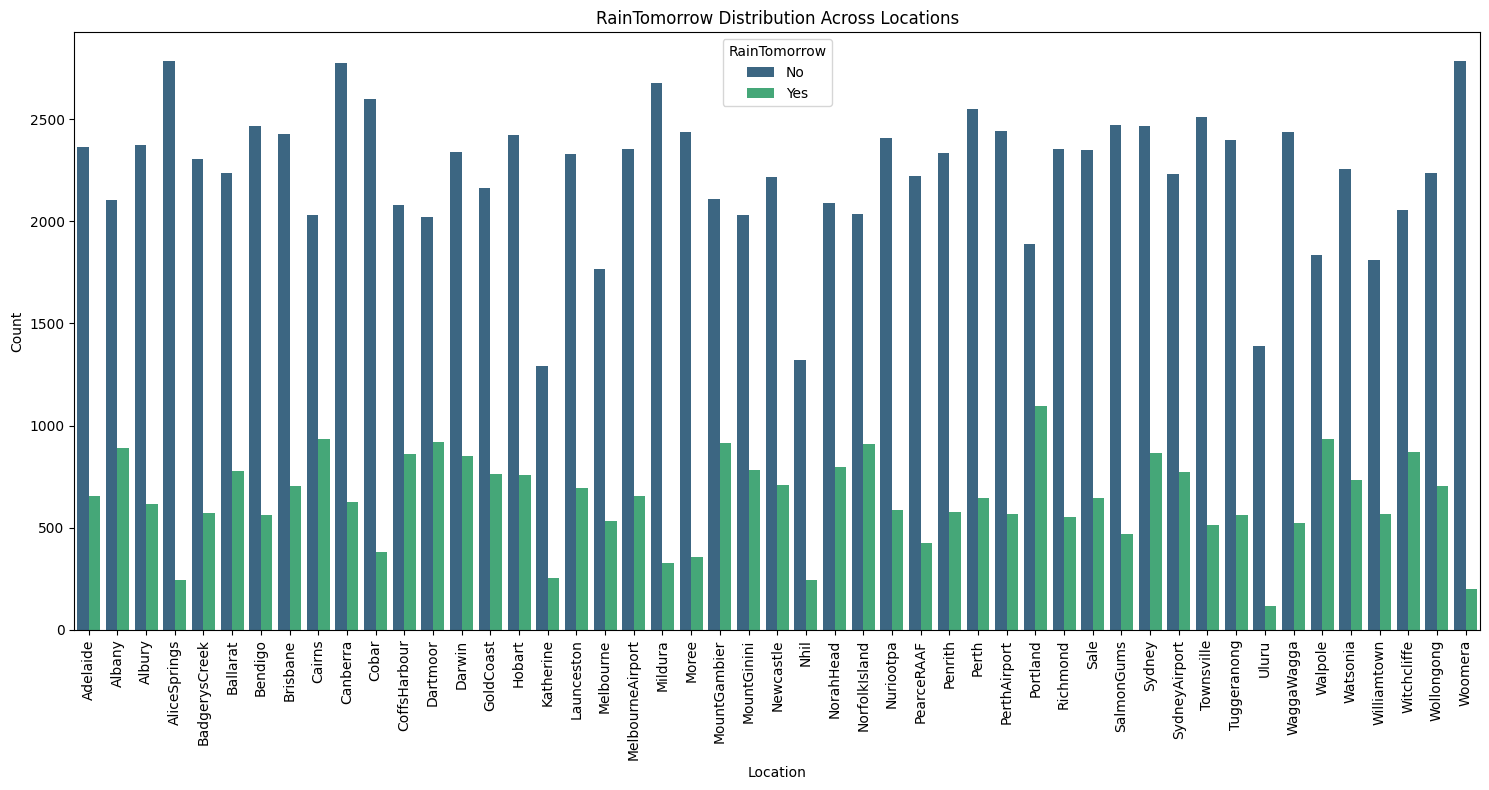

In [93]:
plt.figure(figsize=(15, 8))
sns.countplot(data=df, x='Location', hue='RainTomorrow', palette='viridis')

plt.ylabel('Count')
plt.xticks(rotation=90)
plt.title('RainTomorrow Distribution Across Locations')
plt.tight_layout()
plt.show()

The chart displays the number of days each location was predicted to have rain ("Yes") or no rain ("No") tomorrow. The blue bars represent "No" and the green bars represent "Yes." The height of each bar corresponds to the count of days.

 For nearly all locations, the count of "No" rain days (blue bars) is significantly higher than the count of "Yes" rain days (green bars). This indicates that across the dataset, it was more common for the forecast to predict no rain than rain.

 Sydney, Canberra, and Melbourne appear to have the highest number of days with a "RainTomorrow: Yes" prediction. This could imply that these major cities experienced more frequent rainfall or that more data was collected for them.

 In contrast, locations like Woomera, Watsonia, Walpole, and Cobar have very low "RainTomorrow: Yes" counts. This could indicate a drier climate in these regions or fewer total data points.

 The visualization effectively highlights the uneven distribution of rain events across different Australian locations within the given time frame. It suggests that while no rain is the more frequent forecast overall, the actual frequency of rain predictions varies substantially depending on the location.

***RainToday vs RainTomorrow (to see correlation between consecutive days)***

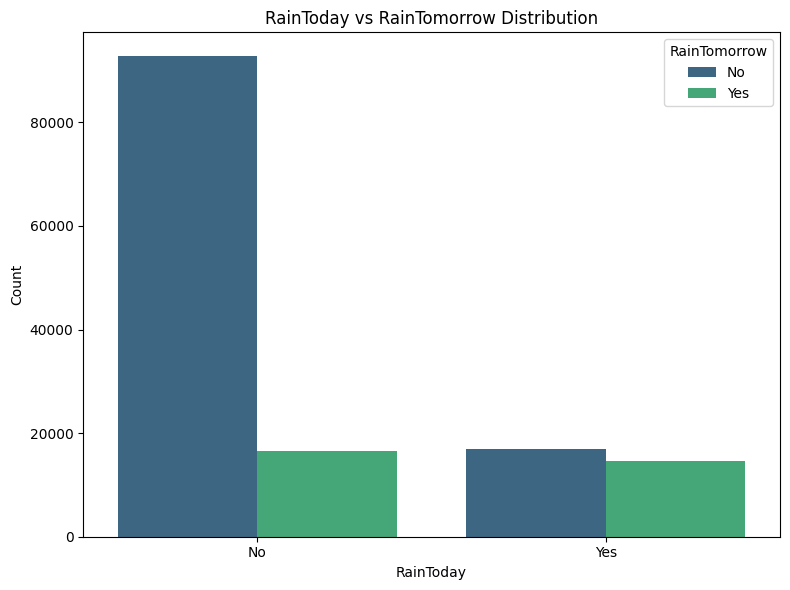

In [94]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='RainToday', hue='RainTomorrow', palette='viridis')

plt.ylabel('Count')
plt.title('RainToday vs RainTomorrow Distribution')
plt.tight_layout()
plt.show()

The largest bar in the entire chart represents days where it did not rain today ("RainToday: No") and is also predicted to not rain tomorrow ("RainTomorrow: No"). This shows that in the majority of cases, a dry day is followed by another dry day.

A much smaller bar represents days where it did not rain today ("RainToday: No") but is predicted to rain tomorrow ("RainTomorrow: Yes"). This indicates that a dry day is less likely to be followed by a rainy day.

The two bars on the right show the distribution when it did rain today. The blue bar represents "RainTomorrow: No" and the green bar represents "RainTomorrow: Yes."

The heights of these two bars are relatively similar, though the "RainTomorrow: Yes" bar is slightly larger. This is a very important insight. It suggests that if it rains today, the chances of it raining tomorrow are roughly equal to, or slightly higher than, the chances of it not raining.

Comparing these bars to the "RainToday: No" bars, we see a dramatic shift. When "RainToday" is "Yes," the proportion of "RainTomorrow: Yes" predictions is significantly higher than when "RainToday" is "No."

***Monthly rain patterns (Month vs RainTomorrow percentage)***

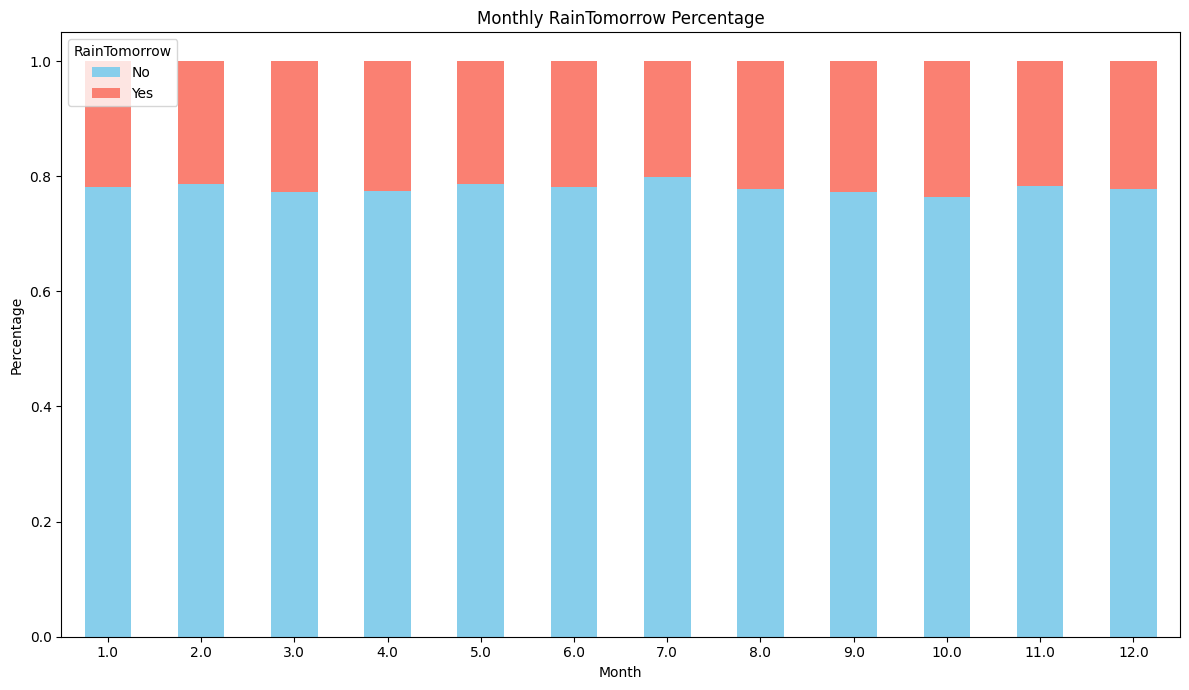

In [95]:
# Calculate the count of RainTomorrow for each month
# Fill missing values in 'Month' with a placeholder before grouping
monthly_rain = df.groupby(['Month', 'RainTomorrow'], observed=False).size().unstack(fill_value=0)

# Calculate the percentage of RainTomorrow for each month
monthly_rain_percent = monthly_rain.apply(lambda x: x / x.sum(), axis=1)

# Create a stacked bar chart
monthly_rain_percent.plot(kind='bar', stacked=True, figsize=(12, 7), color=['skyblue', 'salmon'])

plt.title('Monthly RainTomorrow Percentage')
plt.xlabel('Month')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='RainTomorrow', loc='upper left')
plt.tight_layout()
plt.show()

This stacked bar chart shows how many days in each month, over the 10-year period from 2007 to 2017, were predicted to have rain ("Yes") or no rain ("No") on the following day.

The chart reveals a clear seasonal pattern in rainfall predictions. The number of "RainTomorrow: Yes" predictions (green bars) is significantly higher during the cooler months of the Australian year (April to October), with a peak around June and July. This aligns with the fact that many parts of southern Australia receive more rainfall during winter.

For all months, the count of "RainTomorrow: No" predictions (blue bars) is substantially higher than the "Yes" predictions. This highlights a significant class imbalance in the dataset, meaning that dry days are far more common than rainy days.

The total height of the bars (sum of "Yes" and "No" counts) is relatively consistent across all months, indicating that the dataset has a similar number of observations for each month. This suggests the data collection process was consistent over the period.

***Yearly trends (Year vs RainTomorrow percentage)***

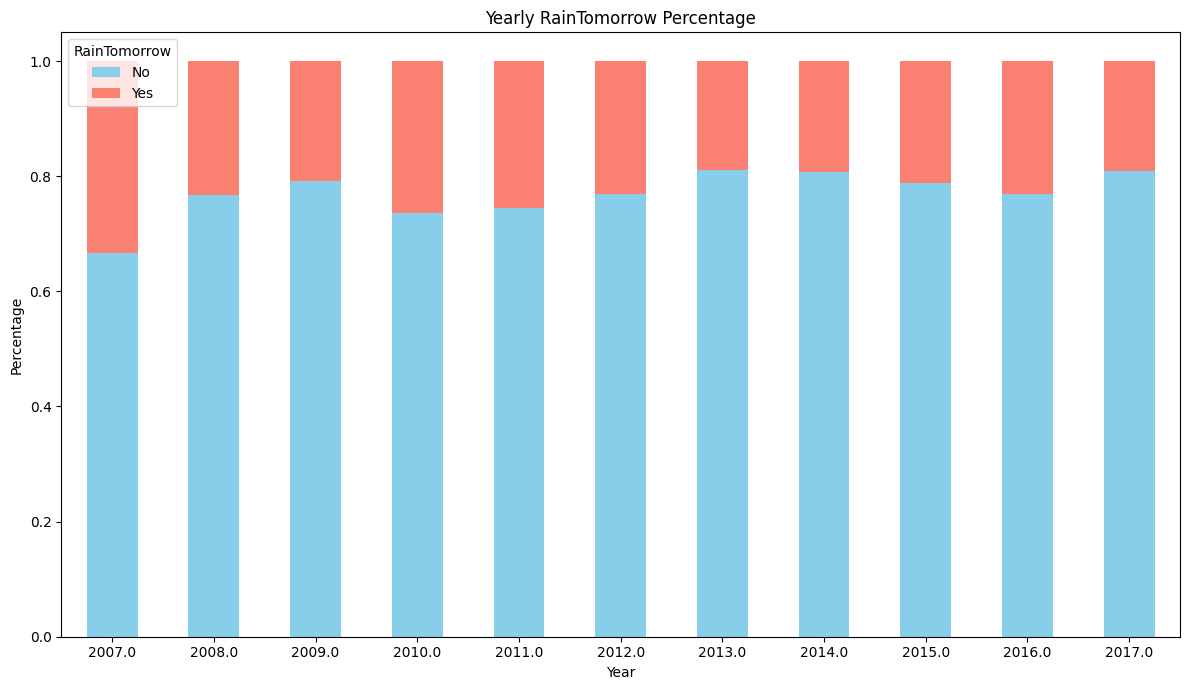

In [96]:
# Calculate the count of RainTomorrow for each year
yearly_rain = df.groupby(['Year', 'RainTomorrow'], observed=False).size().unstack(fill_value=0)

# Calculate the percentage of RainTomorrow for each year
yearly_rain_percent = yearly_rain.apply(lambda x: x / x.sum(), axis=1)

# Create a stacked bar chart
yearly_rain_percent.plot(kind='bar', stacked=True, figsize=(12, 7), color=['skyblue', 'salmon'])

plt.title('Yearly RainTomorrow Percentage')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='RainTomorrow', loc='upper left')
plt.tight_layout()
plt.show()

For every year from 2007 to 2017, the percentage of "RainTomorrow: No" (blue) is significantly higher than "RainTomorrow: Yes" (red/salmon). This reinforces the finding from other charts that the dataset has a considerable class imbalance, with no-rain days being much more common than rainy days.

The proportion of "Yes" and "No" predictions remains fairly stable across the entire period. There are no dramatic spikes or drops in the percentage of rain predictions from one year to the next.
   

*   The "No" percentage consistently hovers between roughly 75% and 80%.
*   The "Yes" percentage remains between 20% and 25%.

While stable, there are some small fluctuations:



*   The percentage of "Yes" predictions appears to be slightly higher in 2007 and 2010.
*   The percentage of "Yes" predictions is slightly lower and the "No" percentage is slightly higher in 2013, 2014, and 2015, suggesting these years might have been slightly drier on average within the dataset.

The chart suggests that over the 10-year period, there was no drastic shift in the overall frequency of rainy days across Australia as represented by this dataset. The general weather patterns remained relatively consistent from a macro perspective.

# **Numerical Variables Distribution**

***Rainfall distribution by RainTomorrow***

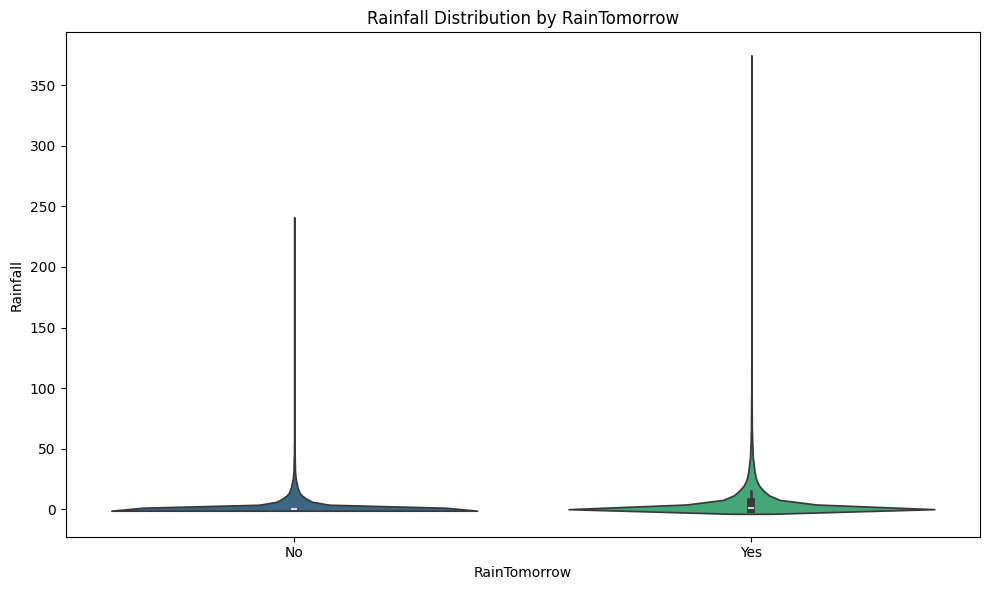

In [97]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='RainTomorrow', y='Rainfall', palette='viridis', hue='RainTomorrow', legend=False)
plt.title('Rainfall Distribution by RainTomorrow')
plt.xlabel('RainTomorrow')
plt.ylabel('Rainfall')
plt.tight_layout()
plt.show()

This plot suggests there's a relationship between current rainfall and tomorrow's rain forecast. Days with very little current rainfall are more likely to have no rain tomorrow, while days with more current rainfall show greater variability in tomorrow's forecast. However, both categories show significant overlap, indicating that current rainfall alone isn't a perfect predictor of tomorrow's weather.

***Temperature variables (MinTemp, MaxTemp, Temp9am, Temp3pm) distribution with RainTomorrow***

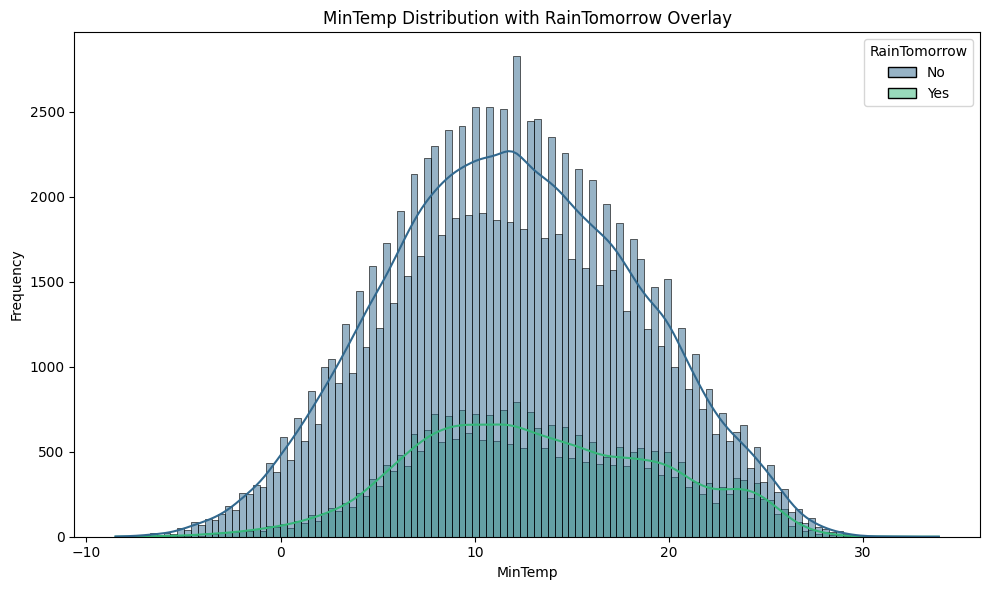

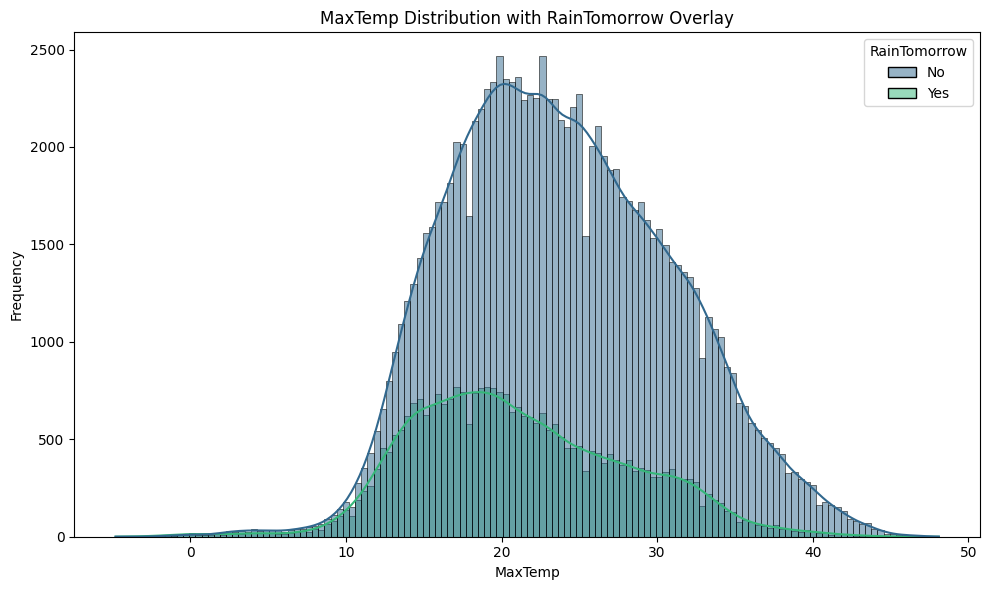

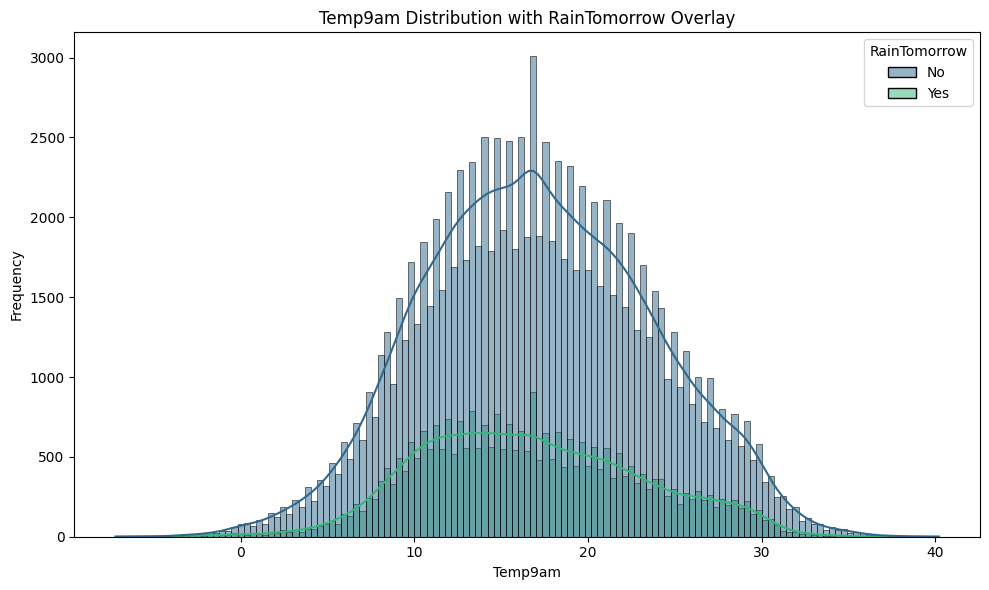

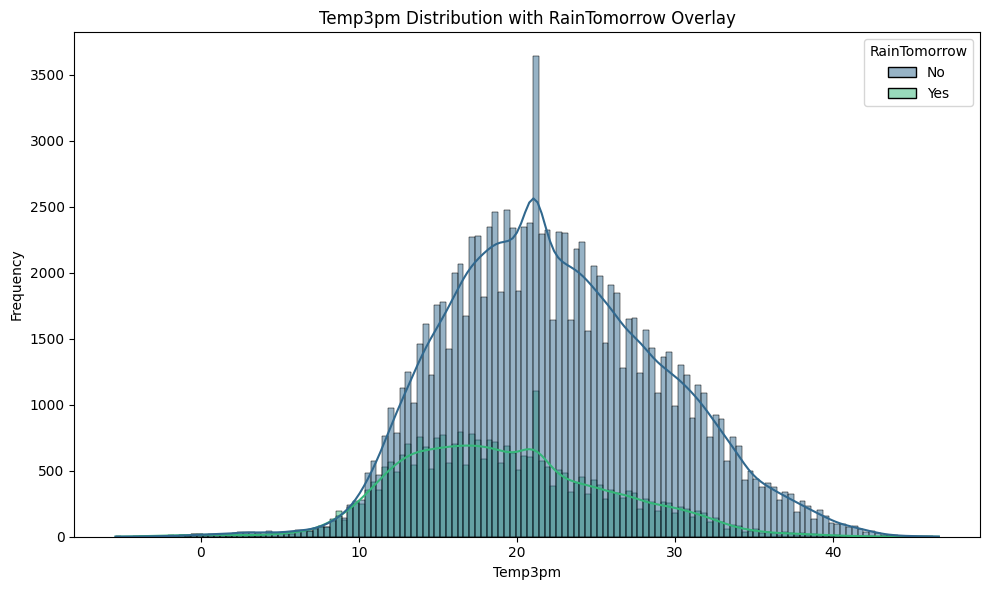

In [98]:
temp_cols = ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm']

for col in temp_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, hue='RainTomorrow', palette='viridis', kde=True)
    plt.title(f'{col} Distribution with RainTomorrow Overlay')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()



   

1.   MinTemp Distribution with RainTomorrow Overlay

    The x-axis represents the minimum temperature (MinTemp).
    The y-axis represents the frequency (count) of days within each temperature range.
    The blue bars and line show the distribution of minimum temperatures for days when it did not rain the next day. This distribution appears somewhat bell-shaped, centered around a moderate minimum temperature.
    The green bars and line show the distribution of minimum temperatures for days when it did rain the next day. This distribution seems to be shifted slightly towards lower minimum temperatures compared to the 'No' distribution, although there is a significant overlap.
    In summary, this chart helps visualize if there is a noticeable difference in minimum temperatures on days preceding a rainy day compared to days preceding a non-rainy day.

2.   MaxTemp Distribution with RainTomorrow Overlay

    This chart shows the distribution of maximum temperature (MaxTemp) for days when it rained the next day (green) and days when it didn't (blue).
    You can see that the distribution for days with no rain tomorrow is shifted towards higher maximum temperatures compared to the distribution for days with rain tomorrow.
    This suggests that higher maximum temperatures are more common on days preceding a non-rainy day.

3.   Temp9am Distribution with RainTomorrow Overlay

    This chart visualizes the distribution of temperature at 9 am (Temp9am), separated by whether it rained the next day ('Yes', green) or not ('No', blue).
    Similar to MinTemp, the distributions largely overlap, but there might be subtle differences in the peaks or spread that indicate a slight tendency for Temp9am to be different on days preceding rain.


4.   Temp3pm Distribution with RainTomorrow Overlay

    This chart shows the distribution of temperature at 3 pm (Temp3pm) for days with and without rain expected the next day.
    Similar to MaxTemp, the distribution for days with no rain tomorrow (blue) is shifted towards higher temperatures compared to days with rain tomorrow (green).
    This suggests that higher temperatures in the afternoon are more frequent when rain is not expected the next day.





***Humidity variables (Humidity9am, Humidity3pm) distribution with RainTomorrow***

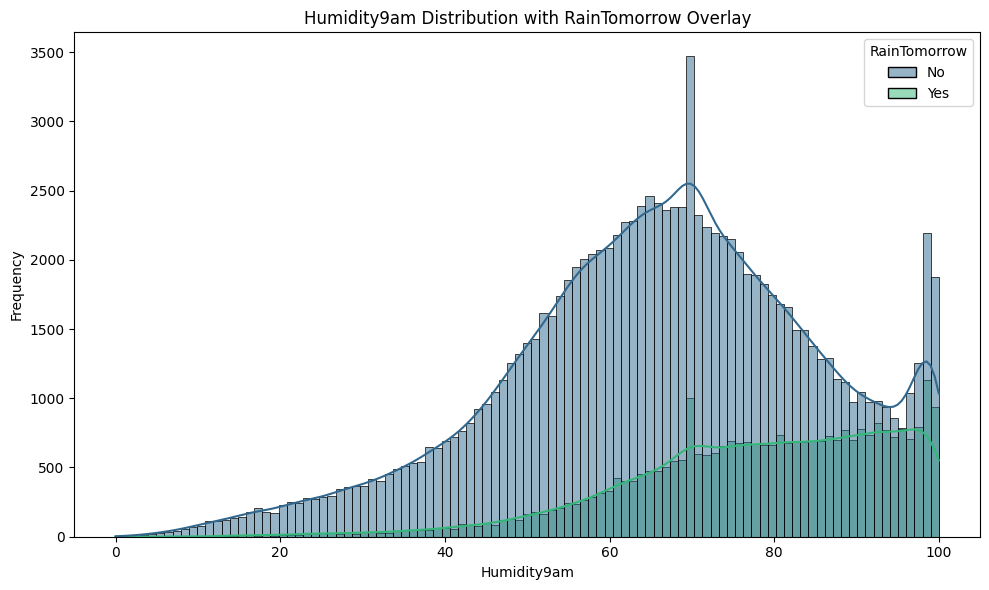

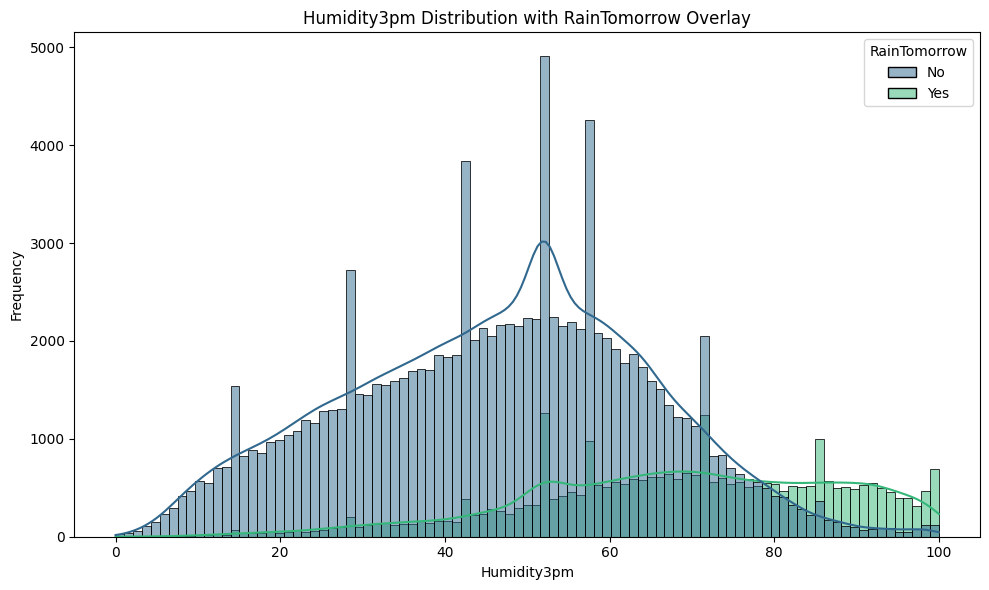

In [99]:
humidity_cols = ['Humidity9am', 'Humidity3pm']

for col in humidity_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, hue='RainTomorrow', palette='viridis', kde=True)
    plt.title(f'{col} Distribution with RainTomorrow Overlay')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()



1.   Humidity9am Distribution with RainTomorrow overlay

    The blue bars and line show the distribution of Humidity9am for days where it was predicted not to rain tomorrow. This distribution has a peak at a moderate humidity level but also shows a significant number of occurrences at lower humidity levels.
    "RainTomorrow: No" (blue) appears to be skewed to the left (negatively skewed). This means that while there's a peak at a moderate humidity level, there's a longer tail extending towards lower humidity values.
    The green bars and line show the distribution of Humidity9am for days where it was predicted to rain tomorrow. This distribution is notably shifted towards higher humidity levels compared to the 'No' distribution and has a peak at a much higher humidity value.
    In summary, both distributions are skewed to the left, but the distribution for days with predicted rain tomorrow is shifted towards higher humidity levels and has less of a tail at the very low end compared to the distribution for days with no predicted rain tomorrow.

2.   Humidity3pm Distribution with RainTomorrow overlay

    The blue bars and line show the distribution of Humidity3pm for days where it was predicted not to rain tomorrow. This distribution is spread across a wider range of humidity values, with peaks at lower to moderate humidity levels.
    Blue bars appears to be skewed to the right (positively skewed). This means that while there are peaks at lower to moderate humidity levels, there's a longer tail extending towards higher humidity values.
    The green bars and line show the distribution of Humidity3pm for days where it was predicted to rain tomorrow. This distribution is significantly shifted towards higher humidity levels compared to the 'No' distribution, with a notable peak at higher humidity values and a concentration of data points at the very high end.
    Green bars appears to be skewed to the left (negatively skewed), with a strong concentration at higher humidity levels and a tail extending towards lower humidity values.
    Similar to Humidity9am, this indicates that higher humidity levels at 3 pm are strongly associated with a higher likelihood of rain the next day. The difference in distributions between 'Yes' and 'No' is quite pronounced, making Humidity3pm another potentially important feature for predicting rain tomorrow.



***Pressure9am\Pressure3pm distribution by RainTomorrow***

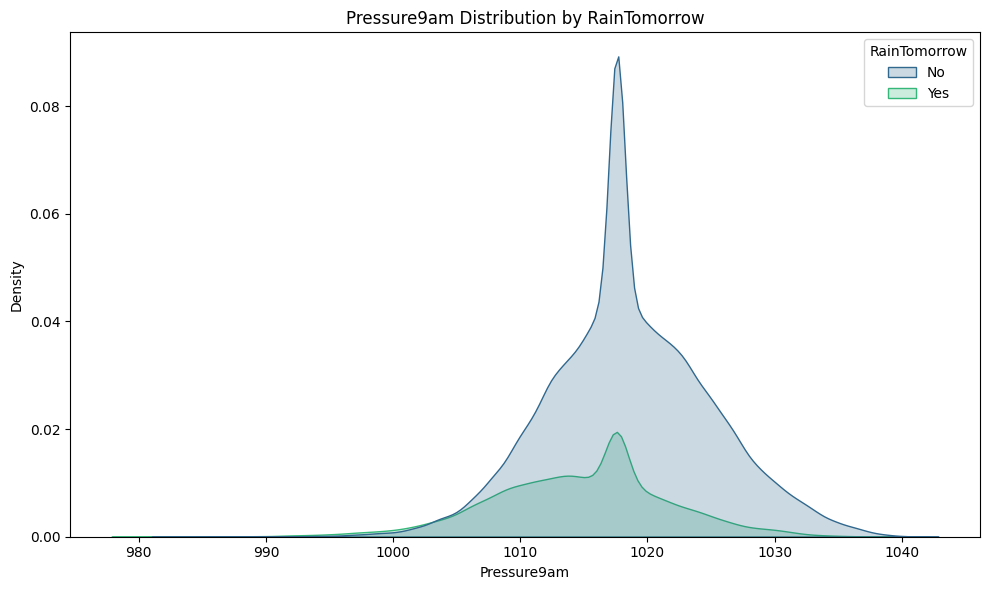

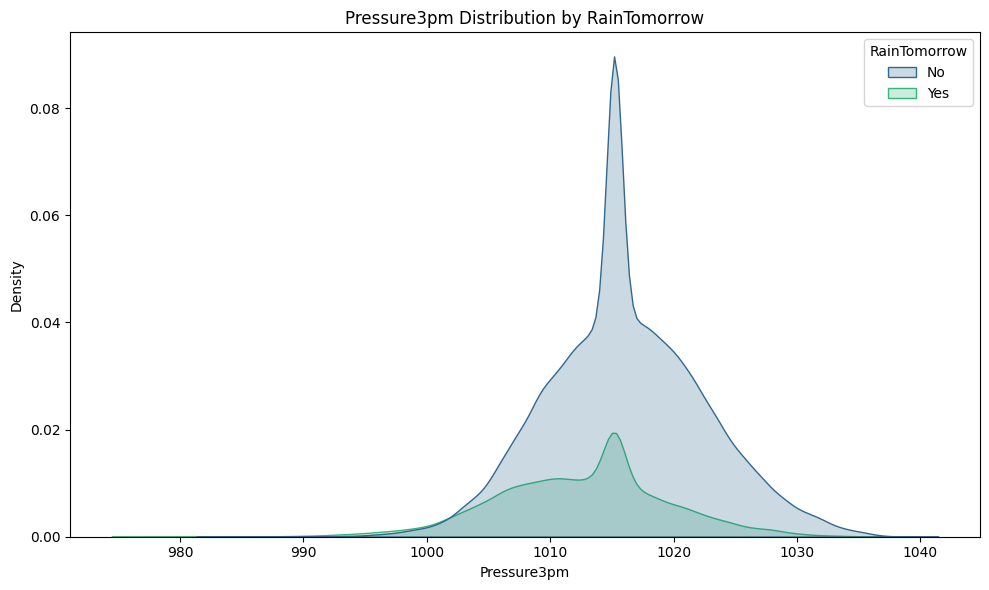

In [100]:
pressure_cols = ['Pressure9am', 'Pressure3pm']

for col in pressure_cols:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df, x=col, hue='RainTomorrow', palette='viridis', fill=True)
    plt.title(f'{col} Distribution by RainTomorrow')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()



1.   Pressure9am Distribution by RainTomorrow

    The blue shaded area represents the distribution of Pressure9am for days where it was predicted not to rain tomorrow. This distribution is centered around a higher pressure value and is relatively narrower.
    The green shaded area represents the distribution of Pressure9am for days where it was predicted to rain tomorrow. This distribution is shifted towards lower pressure values compared to the 'No' distribution and appears broader.
    This indicates that lower atmospheric pressure at 9 am is associated with a higher likelihood of rain the next day, while higher pressure is associated with no rain. The distinct separation and difference in shape between the two density curves suggest that Pressure9am is a relevant feature for predicting rain tomorrow.   

2.    Pressure3pm Distribution by RainTomorrow

    The blue shaded area represents the distribution of Pressure3pm for days where it was predicted not to rain tomorrow. Similar to Pressure9am, this distribution is centered around a higher pressure value.
    The green shaded area represents the distribution of Pressure3pm for days where it was predicted to rain tomorrow. This distribution is also shifted towards lower pressure values compared to the 'No' distribution.
    Similar to Pressure9am, this indicates that lower atmospheric pressure at 3 pm is associated with a higher likelihood of rain the next day, while higher pressure is associated with no rain. The separation between the two density curves suggests that Pressure3pm is also a relevant feature for predicting rain tomorrow.




***WindGustSpeed Distribution by RainTomorrow***

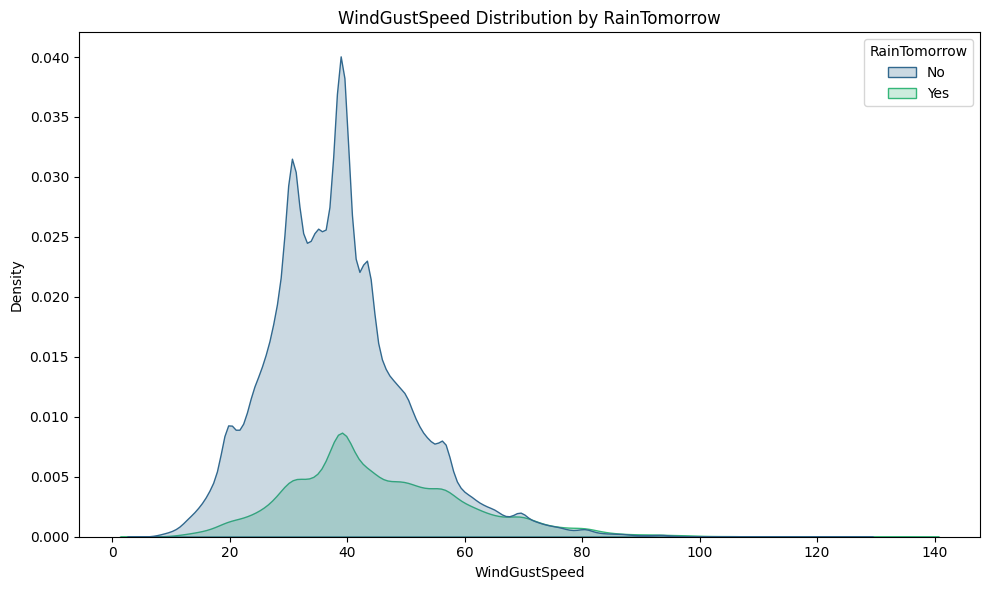

In [101]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='WindGustSpeed', hue='RainTomorrow', palette='viridis', fill=True)
plt.title('WindGustSpeed Distribution by RainTomorrow')
plt.xlabel('WindGustSpeed')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

The blue shaded area represents the distribution of WindGustSpeed for days where it was predicted not to rain tomorrow. This distribution has a peak at a lower wind gust speed and is more concentrated towards lower speeds.

The green shaded area represents the distribution of WindGustSpeed for days where it was predicted to rain tomorrow. This distribution is shifted towards higher wind gust speeds compared to the 'No' distribution and appears broader with a tail extending to higher speeds.

This indicates that higher wind gust speeds are associated with a higher likelihood of rain the next day, while lower wind gust speeds are more common on days preceding no rain. The difference in the shape and position of the two density curves suggests that WindGustSpeed is a relevant feature for predicting rain tomorrow.

***Evaporation and Sunshine Distribution by RainTomorrow***

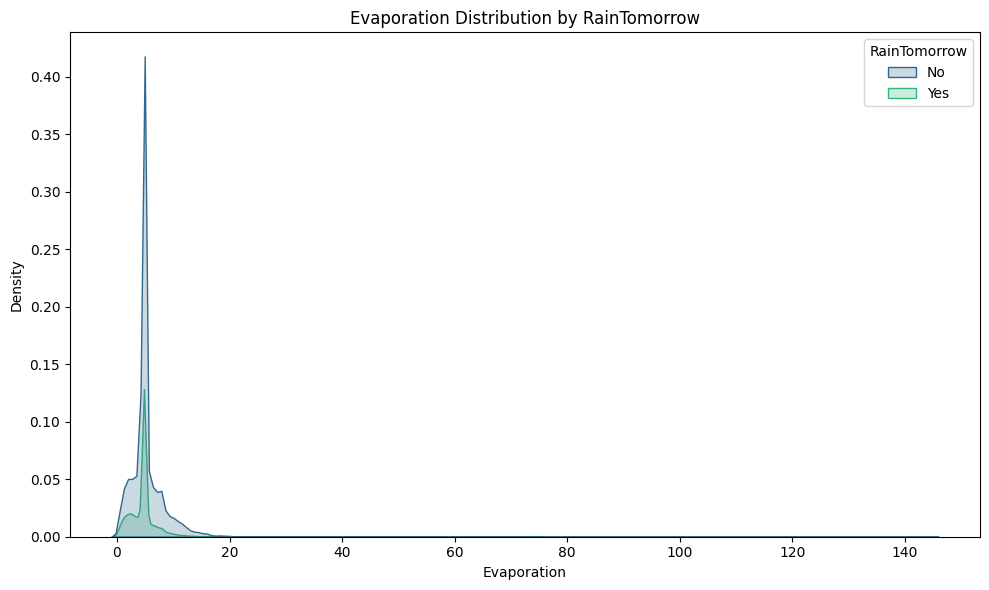

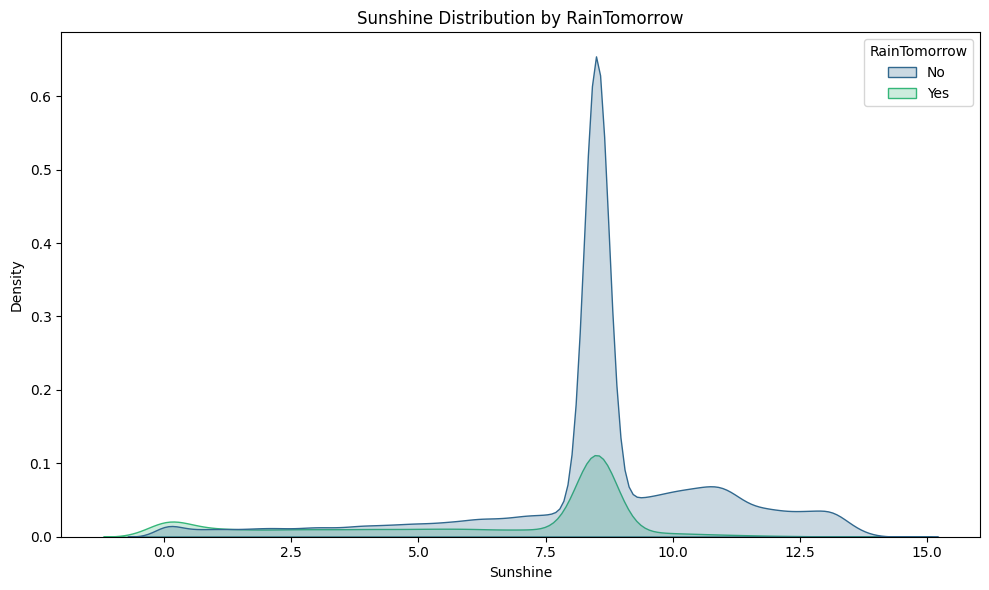

In [102]:
other_cols = ['Evaporation', 'Sunshine']

for col in other_cols:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df, x=col, hue='RainTomorrow', palette='viridis', fill=True)
    plt.title(f'{col} Distribution by RainTomorrow')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()



1.   Evaporation Distribution by RainTomorrow

    The blue shaded area represents the distribution of Evaporation for days where it was predicted not to rain tomorrow. This distribution is heavily concentrated at lower evaporation values and quickly drops off as evaporation increases.
    The green shaded area represents the distribution of Evaporation for days where it was predicted to rain tomorrow. This distribution is also concentrated at lower evaporation values, but the density is lower than the 'No' distribution at the very lowest values and extends slightly further out to higher evaporation values.
    This indicates that lower evaporation amounts are more common on days preceding both rain and no rain. However, the distribution for days with no rain tomorrow is even more skewed towards very low evaporation compared to days with rain tomorrow. This suggests that while high evaporation is generally less frequent, it is even less likely to occur on days followed by rain.

2.   Sunshine Distribution by RainTomorrow

    The blue shaded area represents the distribution of Sunshine for days where it was predicted not to rain tomorrow. This distribution has a clear peak at a higher number of sunshine hours, indicating that sunny days are more common when rain is not expected the next day. There is also a smaller peak at 0 sunshine hours.
    The green shaded area represents the distribution of Sunshine for days where it was predicted to rain tomorrow. This distribution is shifted towards lower sunshine hours, with a significant concentration at 0 sunshine hours and a rapid decrease in density as sunshine hours increase.
    This indicates that days with more sunshine are strongly associated with no rain the next day, while days with less sunshine (or no sunshine) are more associated with rain the next day. The distinct separation between the two density curves makes Sunshine a potentially very useful feature for predicting rain tomorrow.


## **Outlier Detection & Comparison**

***Box Plots of Temperatures by RainTomorrow***

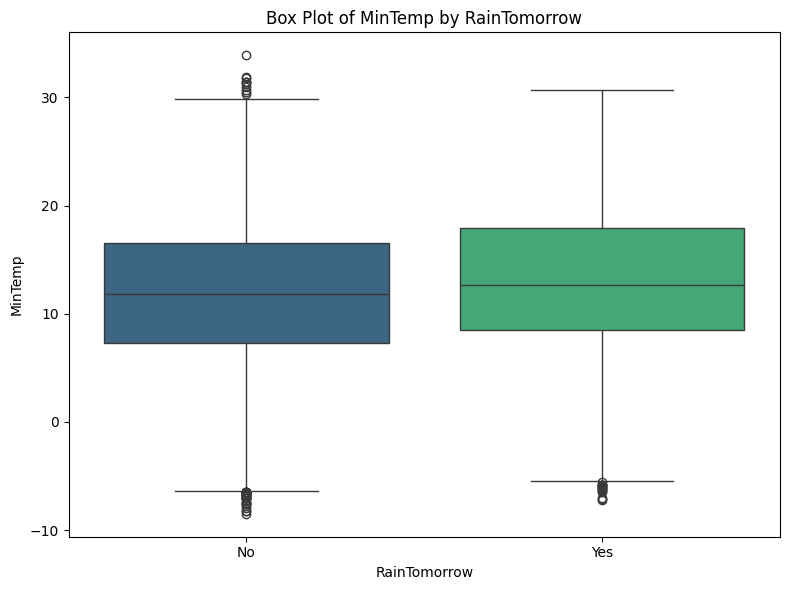

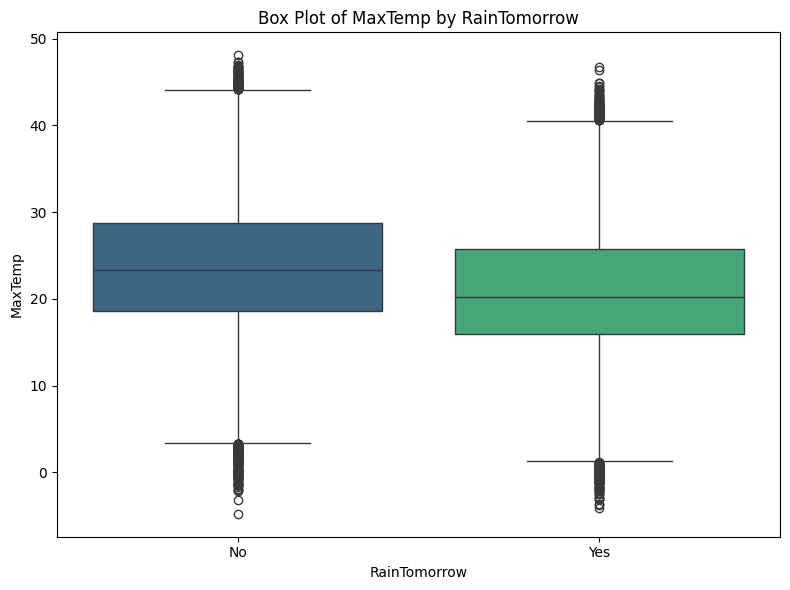

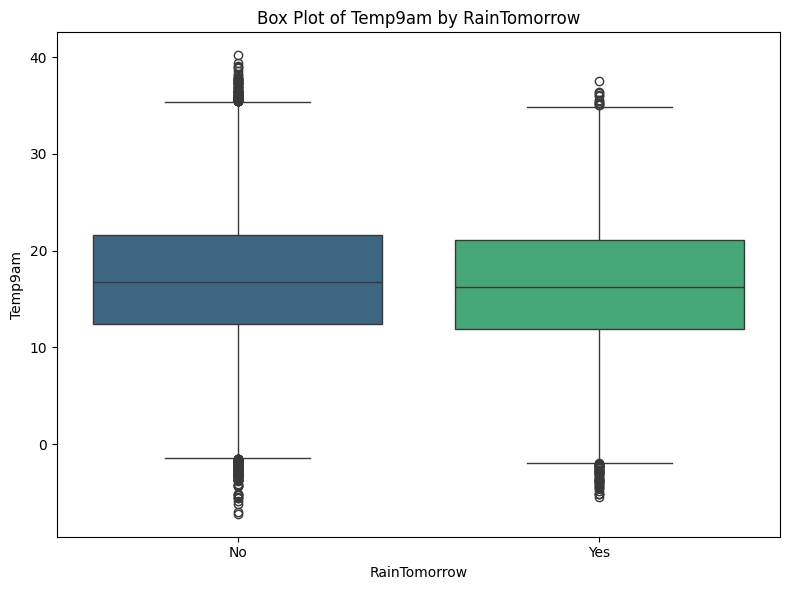

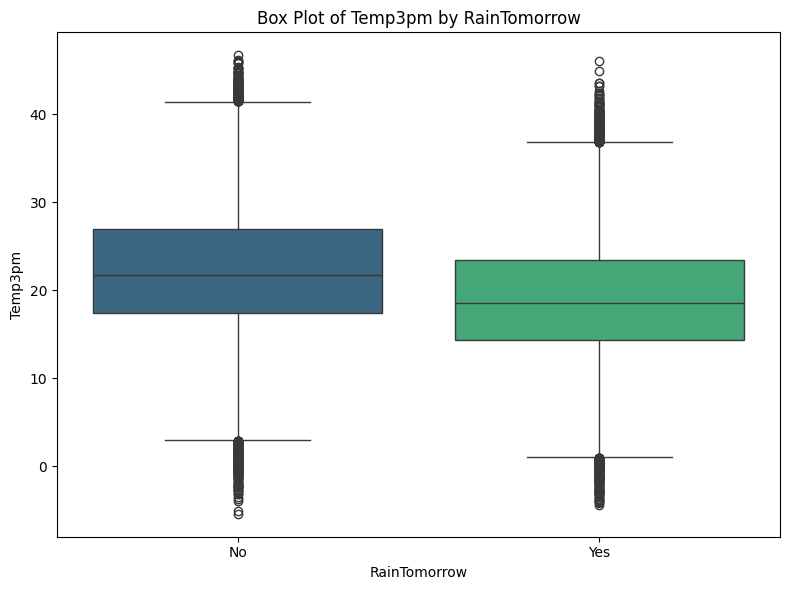

In [103]:
temp_cols = ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm']

for col in temp_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x='RainTomorrow', y=col, palette='viridis', hue='RainTomorrow', legend=False)
    plt.title(f'Box Plot of {col} by RainTomorrow')
    plt.xlabel('RainTomorrow')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()



1.   Box plot of MinTemp by RainTomorrow

    The median line in the 'Yes' box is slightly higher than the median line in the 'No' box. This suggests that the middle temperature on days before rain is slightly warmer than on days before no rain.
    The box for the 'No' group appears slightly wider than the box for the 'Yes' group. This means the middle 50% of MinTemp values has a slightly larger range on days before no rain.
    Both groups exhibit outliers. This means that, regardless of whether rain was expected tomorrow, there were days with exceptionally low or high minimum temperatures    

2.   Box plot of MaxTemp by RainTomorrow

    The median line in the 'No' box is significantly higher than the median line in the 'Yes' box. This suggests that the middle maximum temperature on days before no rain is considerably warmer than on days before rain.
    For the 'No' RainTomorrow (blue box), there are noticeable outliers on both the low and high ends. However, there appear to be more outliers, and potentially outliers with higher values, on the upper end. These represent days with unusually high maximum temperatures when rain was not expected the next day.
    For the 'Yes' RainTomorrow (green box), there are also outliers on both the low and high ends, but they seem less numerous and less extreme on the high end compared to the 'No' group. These represent unusually high or low maximum temperatures when rain was expected the next day.

3.   Box plot of Temp3pm by RainTomorrow

    The median line in the 'No' box appears slightly higher than the median line in the 'Yes' box. This suggests that the middle temperature at 9 am on days before no rain is slightly warmer than on days before rain.
    Both the 'No' and 'Yes' groups show outliers on both the lower and upper ends. There don't appear to be significantly more outliers on one side for either group compared to the other, although there are some extreme values present in both scenarios.

4.   Box plot of Temp3pm by RainTomorrow

    The median Temp3pm for the 'No' (no rain tomorrow) group is noticeably higher than the median Temp3pm for the 'Yes' (rain tomorrow) group. This suggests that on average, temperatures in the afternoon are warmer on days preceding no rain compared to days preceding rain.
    Both the 'No' and 'Yes' groups show outliers on both the lower and upper ends.
    The concentration of upper outliers in the 'No' group reinforces that very high afternoon temperatures are more likely when rain is not expected the following day.


***Box Plots of Humidity by RainTomorrow***

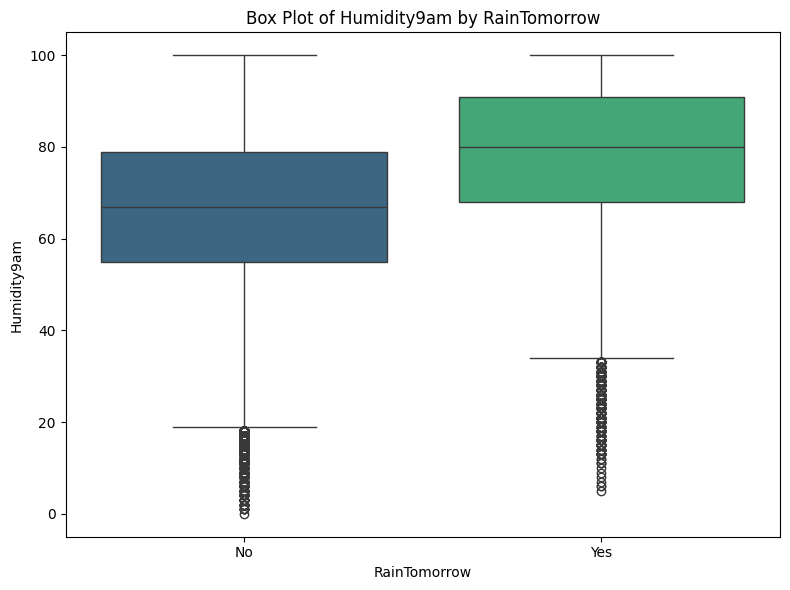

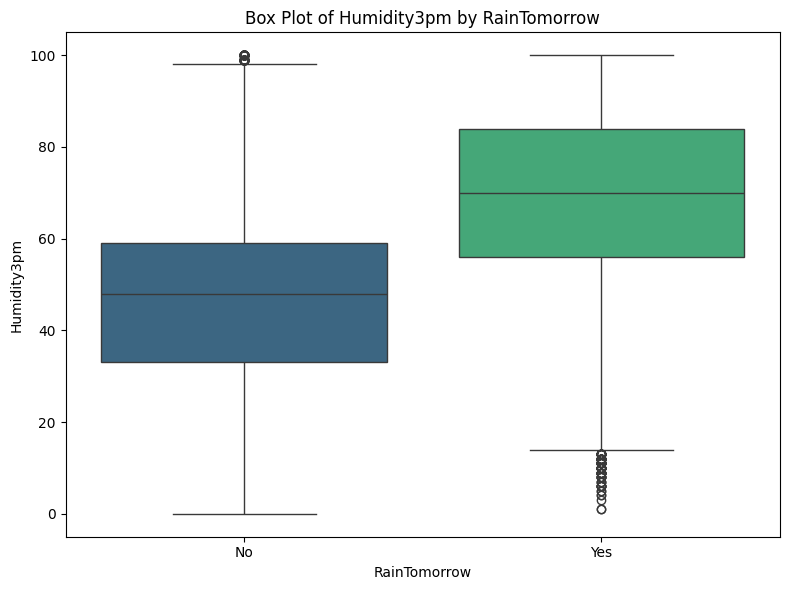

In [104]:
humidity_cols = ['Humidity9am', 'Humidity3pm']

for col in humidity_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x='RainTomorrow', y=col, palette='viridis', hue='RainTomorrow', legend=False)
    plt.title(f'Box Plot of {col} by RainTomorrow')
    plt.xlabel('RainTomorrow')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()



1.   Box Plot of Humidity9am by RainTomorrow

    The median line in the 'Yes' box is significantly higher than the median line in the 'No' box. This indicates that the middle Humidity9am level is considerably higher on days preceding rain compared to days preceding no rain. This is a strong indicator of the relationship between higher morning humidity and the likelihood of rain the next day.
    Both the 'No' and 'Yes' groups show outliers primarily at the lower end of the humidity scale. These represent days with unusually low humidity at 9 am for both categories.


2.   Box Plot of Humidity3pm by RainTomorrow

    The median line in the 'Yes' box is significantly higher than the median line in the 'No' box. This indicates that the middle Humidity3pm level is considerably higher on days preceding rain compared to days preceding no rain. This is a strong indicator that higher humidity in the afternoon is associated with rain the next day.
    Both the 'No' and 'Yes' groups show outliers. The 'No' group has outliers primarily at the very high end of the humidity scale, representing unusually high afternoon humidity on days preceding no rain. The 'Yes' group has outliers primarily at the very low end, representing unusually low afternoon humidity on days preceding rain.



***Box Plots of Wind by RainTomorro***



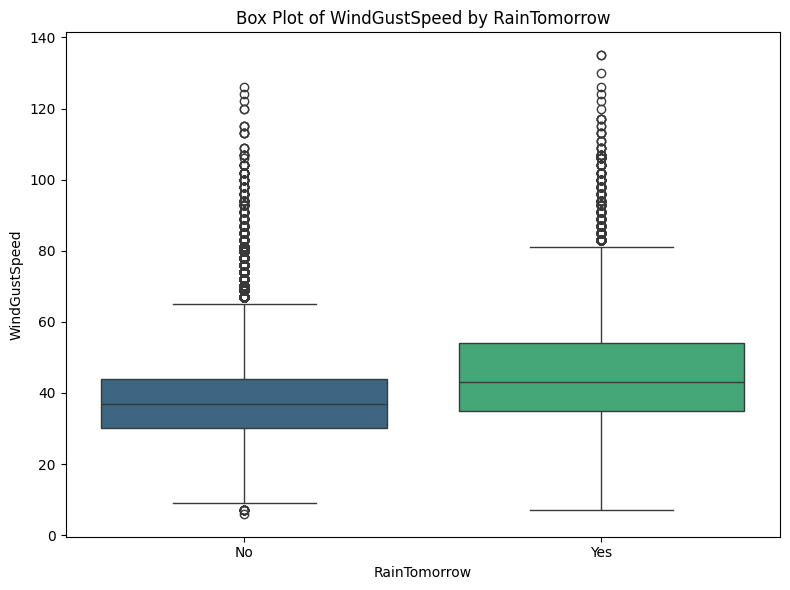

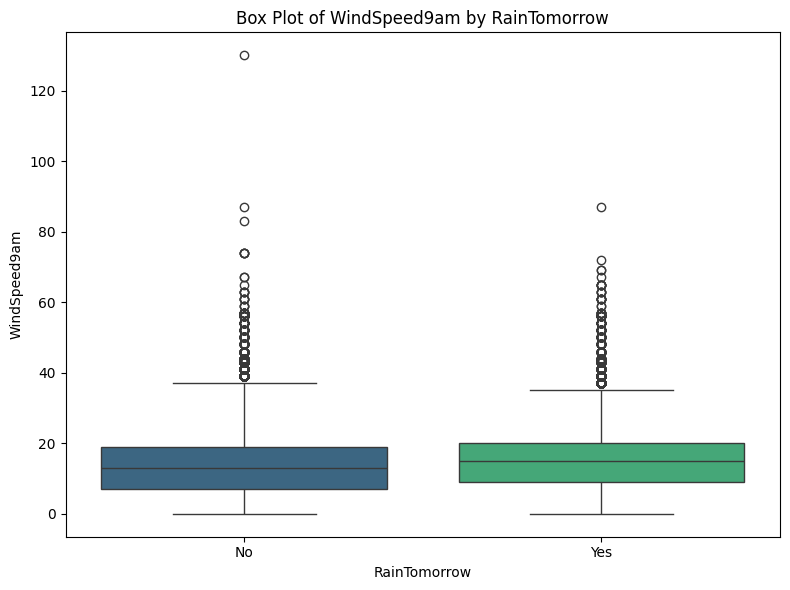

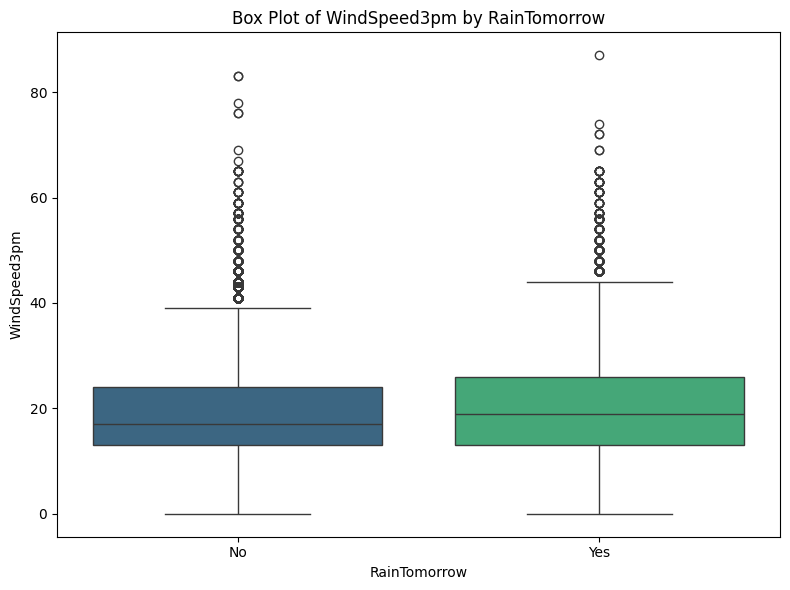

In [105]:
wind_cols = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']

for col in wind_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x='RainTomorrow', y=col, palette='viridis', hue='RainTomorrow', legend=False)
    plt.title(f'Box Plot of {col} by RainTomorrow')
    plt.xlabel('RainTomorrow')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()



1.   Box Plot of WindGuestSpeed by RainTomorrow

    The median line in the 'Yes' box (rain tomorrow, green) appears noticeably higher than the median line in the 'No' box (no rain tomorrow, blue). This suggests that the middle value for wind gust speed is higher on days when rain is expected the next day compared to days when it's not.
    Both the 'No' and 'Yes' groups show a significant number of individual data points (outliers) plotted above their upper whiskers. These represent instances of unusually high wind gust speeds. There appear to be more high outliers, and potentially outliers with higher values, in the 'Yes' group. This indicates that very strong wind gusts are more frequent on days preceding rain tomorrow. There are also some outliers at the very low end for the 'No' group, representing unusually low wind gust speeds.

2.   Box Plot of WindSpeed9am by RainTomorrow

    The median line in the 'Yes' box (rain tomorrow, green) appears slightly higher than the median line in the 'No' box (no rain tomorrow, blue). This suggests that the middle value for wind speed at 9 am is slightly higher on days when rain is expected the next day compared to days when it's not.
    Both the 'No' and 'Yes' groups show a significant number of individual data points (outliers) plotted above their upper whiskers. These represent instances of unusually high wind speeds at 9 am. There appear to be a comparable number of high outliers in both the 'No' and 'Yes' groups, with some very extreme values present in both.


3.   Box Plot of WindSpeed3m by RainTomorrow

    The median line in the 'Yes' box (rain tomorrow, green) appears noticeably higher than the median line in the 'No' box (no rain tomorrow, blue). This suggests that the middle value for wind speed at 3 pm is higher on days when rain is expected the next day compared to days when it's not.
    Both the 'No' and 'Yes' groups show a significant number of individual data points (outliers) plotted above their upper whiskers. These represent instances of unusually high wind speeds at 3 pm. There appear to be a comparable number of high outliers in both the 'No' and 'Yes' groups, with some very extreme values present in both.


***Box Plots of Atmospheric Features by RainTomorrow***

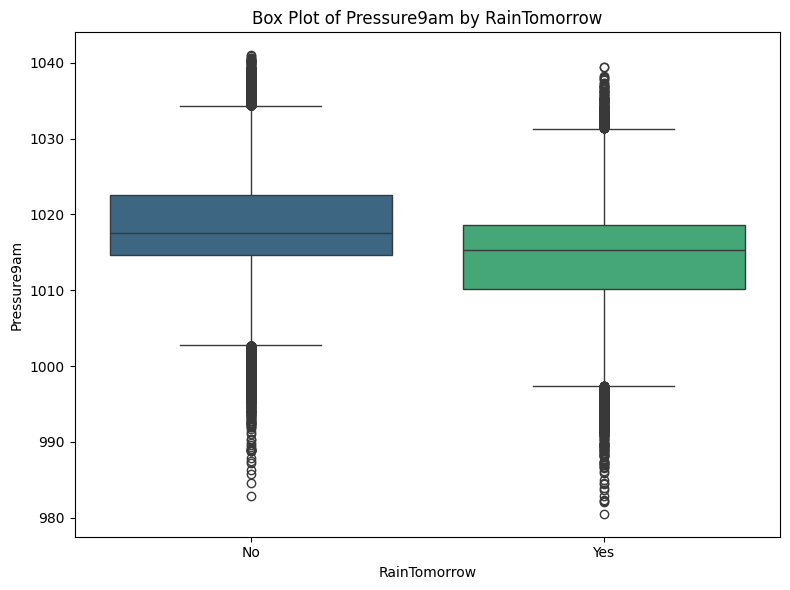

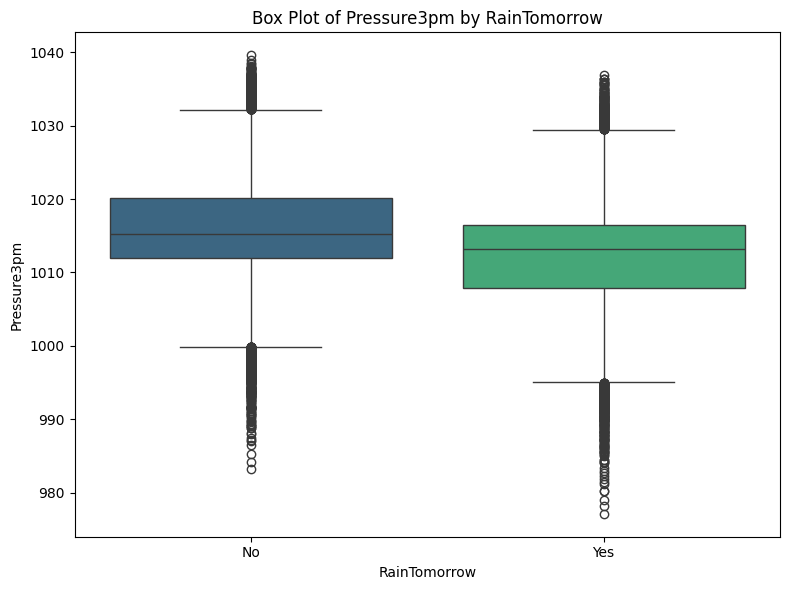

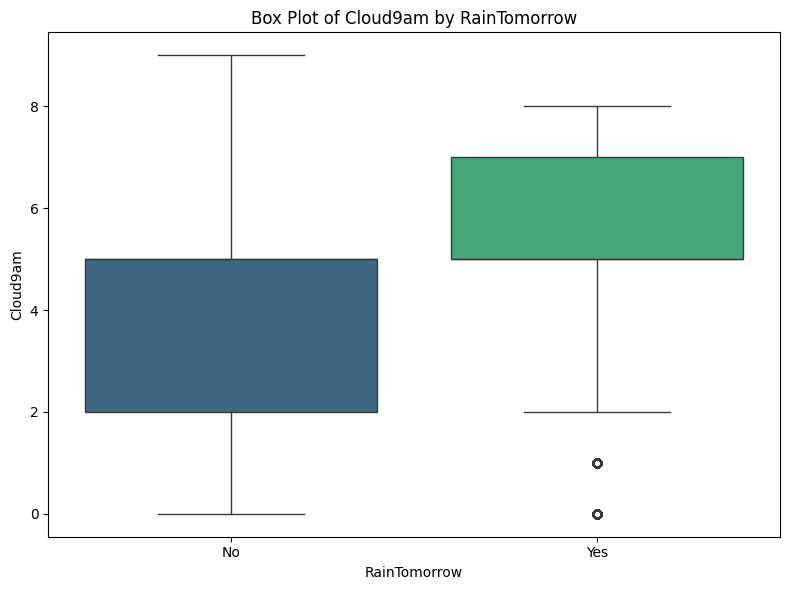

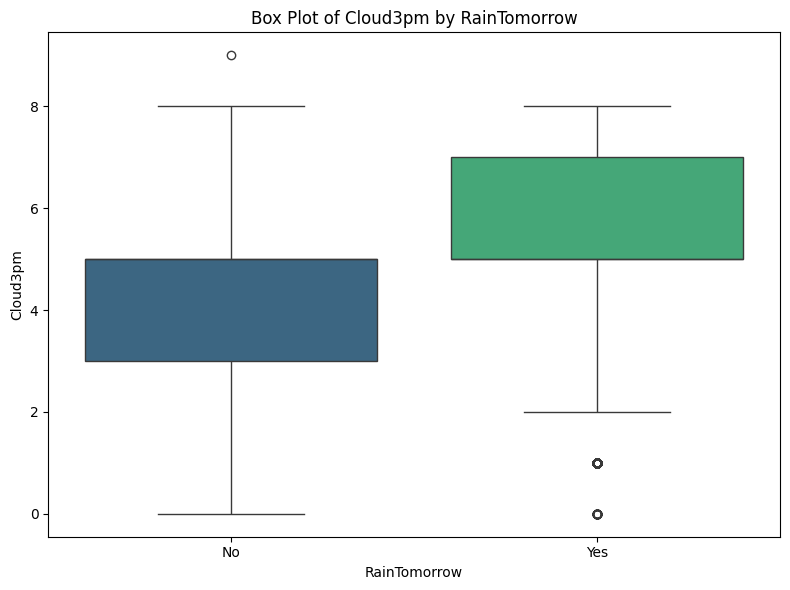

In [106]:
atmospheric_cols = ['Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm']

for col in atmospheric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x='RainTomorrow', y=col, palette='viridis', hue='RainTomorrow', legend=False)
    plt.title(f'Box Plot of {col} by RainTomorrow')
    plt.xlabel('RainTomorrow')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()



1.   Box Plot of Pressure9am by  RainTomorrow

    The median line in the 'No' box (no rain tomorrow, blue) is noticeably higher than the median line in the 'Yes' box (rain tomorrow, green). This suggests that the middle value for pressure at 9 am is higher on days when rain is not expected the next day compared to days when it is.
    Both the 'No' and 'Yes' groups show a significant number of individual data points (outliers) plotted both below the lower whisker and above the upper whisker. These represent instances of unusually low or high pressure at 9 am. There appear to be outliers on both ends for both groups, indicating that extreme pressure values occurred regardless of whether it rained the next day.


2.   Box Plot of Pressure3pm by  RainTomorrow

    The median line in the 'No' box (no rain tomorrow, blue) is noticeably higher than the median line in the 'Yes' box (rain tomorrow, green). This suggests that the middle value for pressure at 3 pm is higher on days when rain is not expected the next day compared to days when it is. Similar to Pressure9am, lower pressure at 3 pm is associated with rain the next day.
    Both the 'No' and 'Yes' groups show a significant number of individual data points (outliers) plotted both below the lower whisker and above the upper whisker. These represent instances of unusually low or high pressure at 3 pm. There appear to be outliers on both ends for both groups, indicating that extreme pressure values occurred regardless of whether it rained the next day.


3.   Box Plot of Cloud9am by  RainTomorrow

    The 'No' group (blue box) shows no outliers. The 'Yes' group (green box) shows some outliers at the lower end of cloud cover (values near 0 and 1).
    



4.   Box Plot of Cloud3pm by  RainTomorrow

    The 'No' group (blue box) shows outliers primarily at the higher end of cloud cover (values near 9). The 'Yes' group (green box) shows some outliers at the lower end of cloud cover (values near 0 and 1).
